In [185]:
library(ComplexHeatmap)
library(circlize)
#library(gridExtra)
library(RColorBrewer)
library(ggpubr)
library(tidyverse)
library(ggplot2)
library(dplyr)
library(corrplot)
library(circlize)
library(stringr)
library(tidyr)
library(ggpubr)
library(readr)
library(rstatix)

In [205]:
# ---- Load genomic arm coordinates ----
arm_lengths <- read_tsv("/home/mjehangir/softwares/Arm-Level-Aneuploidy/data/genomic_arm_coordinates_hg19.txt", col_types = cols()) %>%
  rename(chrom = chrom, arm = arm, arm_start = start, arm_end = end) %>%
  mutate(arm_length = arm_end - arm_start)
head(arm_lengths)

chrom,side,arm,arm_start,arm_end,arm_length
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
chr1,p,1p,0.00e+00,125000000,125000000
chr1,q,1q,1.25e+08,249250621,124250621
chr10,p,10p,0.00e+00,40200000,40200000
chr10,q,10q,4.02e+07,135534747,95334747
chr11,p,11p,0.00e+00,53700000,53700000
chr11,q,11q,5.37e+07,135006516,81306516


In [206]:
setwd("/scratch/mjehangir/tcga/gliomas_subtypes")


In [207]:


genome_size <- sum(arm_lengths$arm_length)

# Load CNV data as before
files <- list.files(pattern = "_(primary|recurrence).seg$")
cnv_all <- do.call(rbind, lapply(files, function(file) {
  df <- read.table(file, header = TRUE, sep = "\t")
  df$tumor_type <- case_when(
    grepl("astro", file, ignore.case = TRUE) ~ "Astrocytoma",
    grepl("oligo", file, ignore.case = TRUE) ~ "Oligodendroglioma",
    grepl("glioblastoma", file, ignore.case = TRUE) ~ "GBM",
    TRUE ~ "Other"
  )
  df$stage <- ifelse(grepl("primary", file, ignore.case = TRUE), "Primary", "Recurrence")
  df$sample <- df$ID
  df$row_id <- paste0(file, "_", seq_len(nrow(df)))  # unique id
  df
}))

cnv_all <- cnv_all %>%
  mutate(chrom = ifelse(grepl("^chr", chrom), chrom, paste0("chr", chrom)),
         segment_length = loc.end - loc.start)

# Join with arm coordinates & calculate overlap
cnv_with_arms <- cnv_all %>%
  left_join(arm_lengths, by = "chrom") %>%
  filter(loc.start < arm_end & loc.end > arm_start) %>%
  mutate(
    overlap_start = pmax(loc.start, arm_start),
    overlap_end = pmin(loc.end, arm_end),
    overlap_len = pmax(0, overlap_end - overlap_start),
    arm_fraction = overlap_len / arm_length
  )
head(cnv_with_arms)


Warning message in left_join(., arm_lengths, by = "chrom"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


,ID,chrom,loc.start,loc.end,num.mark,seg.mean,tumor_type,stage,sample,row_id,segment_length,side,arm,arm_start,arm_end,arm_length,overlap_start,overlap_end,overlap_len,arm_fraction
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TCGA-CS-4938-01,chr1,3218610,91104026,50505,0.0027,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_1,87885416,p,1p,0.00e+00,125000000,125000000,3218610,91104026,87885416,0.703083328
2,TCGA-CS-4938-01,chr1,91108204,91109793,2,-1.3703,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_2,1589,p,1p,0.00e+00,125000000,125000000,91108204,91109793,1589,0.000012712
3,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,156700937,p,1p,0.00e+00,125000000,125000000,91112769,125000000,33887231,0.271097848
4,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,156700937,q,1q,1.25e+08,249250621,124250621,125000000,247813706,122813706,0.988435350
5,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,105662085,p,2p,0.00e+00,93300000,93300000,484222,93300000,92815778,0.994810054
6,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,105662085,q,2q,9.33e+07,243199373,149899373,93300000,106146307,12846307,0.085699538


In [208]:
arm_level_threshold <- 0.3

cnv_with_arms <- cnv_with_arms %>%
  mutate(
    cna_status = ifelse(seg.mean > 0, 1, ifelse(seg.mean < 0, -1, 0))
  )


In [209]:
arm_level_cnvs <- cnv_with_arms %>%
  filter(arm_fraction >= 0.8 & abs(seg.mean) >= arm_level_threshold) %>%
  select(sample, tumor_type, stage, chrom, arm, cna_status) %>%
  unite(region, chrom, arm, sep = "_")

partial_cnvs <- cnv_with_arms %>%
  filter(arm_fraction < 0.8 & arm_fraction > 0 & abs(seg.mean) >= arm_level_threshold) %>%
  select(sample, tumor_type, stage, chrom, arm, cna_status) %>%
  unite(region, chrom, arm, sep = "_")


In [210]:


arm_level_mat <- arm_level_cnvs %>%
  group_by(sample, region) %>%
  summarise(cna_status = max(abs(cna_status)) * sign(cna_status[cna_status != 0][1]), .groups = "drop") %>%
  pivot_wider(names_from = region, values_from = cna_status, values_fill = 0) %>%
  column_to_rownames("sample") %>%
  as.matrix()


In [211]:
partial_mat <- partial_cnvs %>%
  group_by(sample, region) %>%
  summarise(cna_status = max(abs(cna_status)) * sign(cna_status[cna_status != 0][1]), .groups = "drop") %>%
  pivot_wider(names_from = region, values_from = cna_status, values_fill = 0) %>%
  column_to_rownames("sample") %>%
  as.matrix()
head(partial_mat)

,chr10_10p,chr10_10q,chr11_11p,chr11_11q,chr12_12p,chr12_12q,chr13_13q,chr14_14q,chr15_15q,chr16_16p,⋯,chr7_7q,chr8_8p,chr8_8q,chr9_9p,chr9_9q,chr22_22q,chr21_21p,chr21_21q,chrX_Xp,chrX_Xq
GLSS-19-0266-R1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,0,0,0,0,0
GLSS-19-0266-TP,0,-1,0,0,0,0,0,1,0,0,⋯,0,0,0,-1,0,0,0,0,0,0
GLSS-19-0267-R1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,0,0
GLSS-19-0267-TP,0,-1,0,0,0,0,0,-1,-1,0,⋯,0,0,-1,-1,0,-1,0,0,0,0
GLSS-19-0268-R1,0,0,0,0,0,0,0,0,0,0,⋯,-1,0,0,0,0,0,0,0,0,0
GLSS-19-0268-TP,-1,-1,0,0,0,-1,0,0,0,0,⋯,1,0,0,-1,-1,-1,1,0,0,0


In [212]:
library(tidyverse)
library(ComplexHeatmap)
library(circlize)
library(cowplot)

# --- Assuming these data frames exist from your previous steps: ---
# arm_level_cnvs (columns: sample, tumor_type, stage, region, cna_status)
# partial_cnvs (same columns)
# measures (sample, tumor_type, stage, aneuploidy_fraction, percent_genome_altered)

# --- Step 1: Prepare matrices for heatmaps ---

arm_level_mat <- arm_level_cnvs %>%
  group_by(sample, region) %>%
  summarise(cna_status = first(cna_status), .groups = "drop") %>%
  pivot_wider(names_from = region, values_from = cna_status, values_fill = 0) %>%
  column_to_rownames("sample") %>%
  as.matrix()

partial_mat <- partial_cnvs %>%
  group_by(sample, region) %>%
  summarise(cna_status = first(cna_status), .groups = "drop") %>%
  pivot_wider(names_from = region, values_from = cna_status, values_fill = 0) %>%
  column_to_rownames("sample") %>%
  as.matrix()

# --- Step 2: Get common samples to match rows in both matrices ---

common_samples <- intersect(rownames(arm_level_mat), rownames(partial_mat))

arm_level_mat_sub <- arm_level_mat[common_samples, , drop = FALSE]
partial_mat_sub <- partial_mat[common_samples, , drop = FALSE]

# --- Helper function to get tumor type in correct order ---
get_tumor_type <- function(samples, df) {
  df %>%
    distinct(sample, tumor_type) %>%
    filter(sample %in% samples) %>%
    arrange(factor(sample, levels = samples)) %>%
    pull(tumor_type)
}

tumor_colors <- c("GBM" = "#E41A1C", "Astrocytoma" = "#377EB8", "Oligodendroglioma" = "#4DAF4A")

# --- Step 3: Create row annotations for subset samples ---

ha_arm_row_sub <- rowAnnotation(
  TumorType = factor(get_tumor_type(common_samples, arm_level_cnvs),
                     levels = names(tumor_colors)),
  col = list(TumorType = tumor_colors),
  show_annotation_name = TRUE
)

ha_partial_row_sub <- rowAnnotation(
  TumorType = factor(get_tumor_type(common_samples, partial_cnvs),
                     levels = names(tumor_colors)),
  col = list(TumorType = tumor_colors),
  show_annotation_name = TRUE
)

# --- Step 4: Define CNA color function ---
col_fun <- colorRamp2(c(-1, 0, 1), c("blue", "white", "red"))
library(ComplexHeatmap)
library(circlize)
library(dplyr)

# --- Step 5: Create CNA Heatmap with tumor type grouping ---

# Ensure sample order matches metadata
partial_mat_ordered <- partial_mat[measures_filt$ID, ]

# Annotation for tumor types
tumor_anno <- HeatmapAnnotation(
  Tumor = measures_filt$tumor_type,
  col = list(Tumor = tumor_colors),
  which = "row",
  show_annotation_name = FALSE
)

# --- Step 6: Boxplots for genomic instability metrics ---

measures_filt <- measures %>%
  filter(tumor_type %in% c("Astrocytoma", "GBM", "Oligodendroglioma"))


head(measures_filt)

,sample,tumor_type,stage,aneuploidy_score,genome_altered_bp,percent_genome_altered,num_cnvs,aneuploidy_fraction
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TCGA-CS-4938-01,Astrocytoma,Primary,1,150498361,4.861565,35,0.02083333
2,TCGA-CS-4942-01,Astrocytoma,Primary,1,271831535,8.781003,21,0.02083333
3,TCGA-CS-4943-01,Astrocytoma,Primary,2,752266376,24.300542,145,0.04166667
4,TCGA-CS-4944-01,Astrocytoma,Primary,0,173302552,5.598211,28,0.00000000
5,TCGA-CS-5393-01,Astrocytoma,Primary,0,167691656,5.416962,107,0.00000000
6,TCGA-CS-5394-01,Astrocytoma,Primary,0,171351390,5.535182,27,0.00000000


In [213]:
# Step 1: Define desired chromosome arm order (1p, 1q, ..., Xp, Xq)
arm_order <- paste0(rep(c(1:22, "X", "Y"), each = 2), rep(c("p", "q"), times = 24))

# Step 2: Clean up column names to 1p, 1q, etc.
clean_colnames <- function(cols) {
  cols <- gsub("^chr(\\d+)_\\1", "\\1", cols)  # chr7_7p → 7p
  cols <- gsub("^chrX_X", "X", cols)
  cols <- gsub("^chrY_Y", "Y", cols)
  return(cols)
}

# Apply to both matrices
colnames(arm_level_mat_sub) <- clean_colnames(colnames(arm_level_mat_sub))
colnames(partial_mat_sub) <- clean_colnames(colnames(partial_mat_sub))

# Step 3: Reorder columns based on desired arm order
# Keep only columns that exist in the matrix and in our defined order
valid_arm_cols <- intersect(arm_order, colnames(arm_level_mat_sub))
arm_level_mat_sub <- arm_level_mat_sub[, valid_arm_cols]

valid_partial_cols <- intersect(arm_order, colnames(partial_mat_sub))
partial_mat_sub <- partial_mat_sub[, valid_partial_cols]


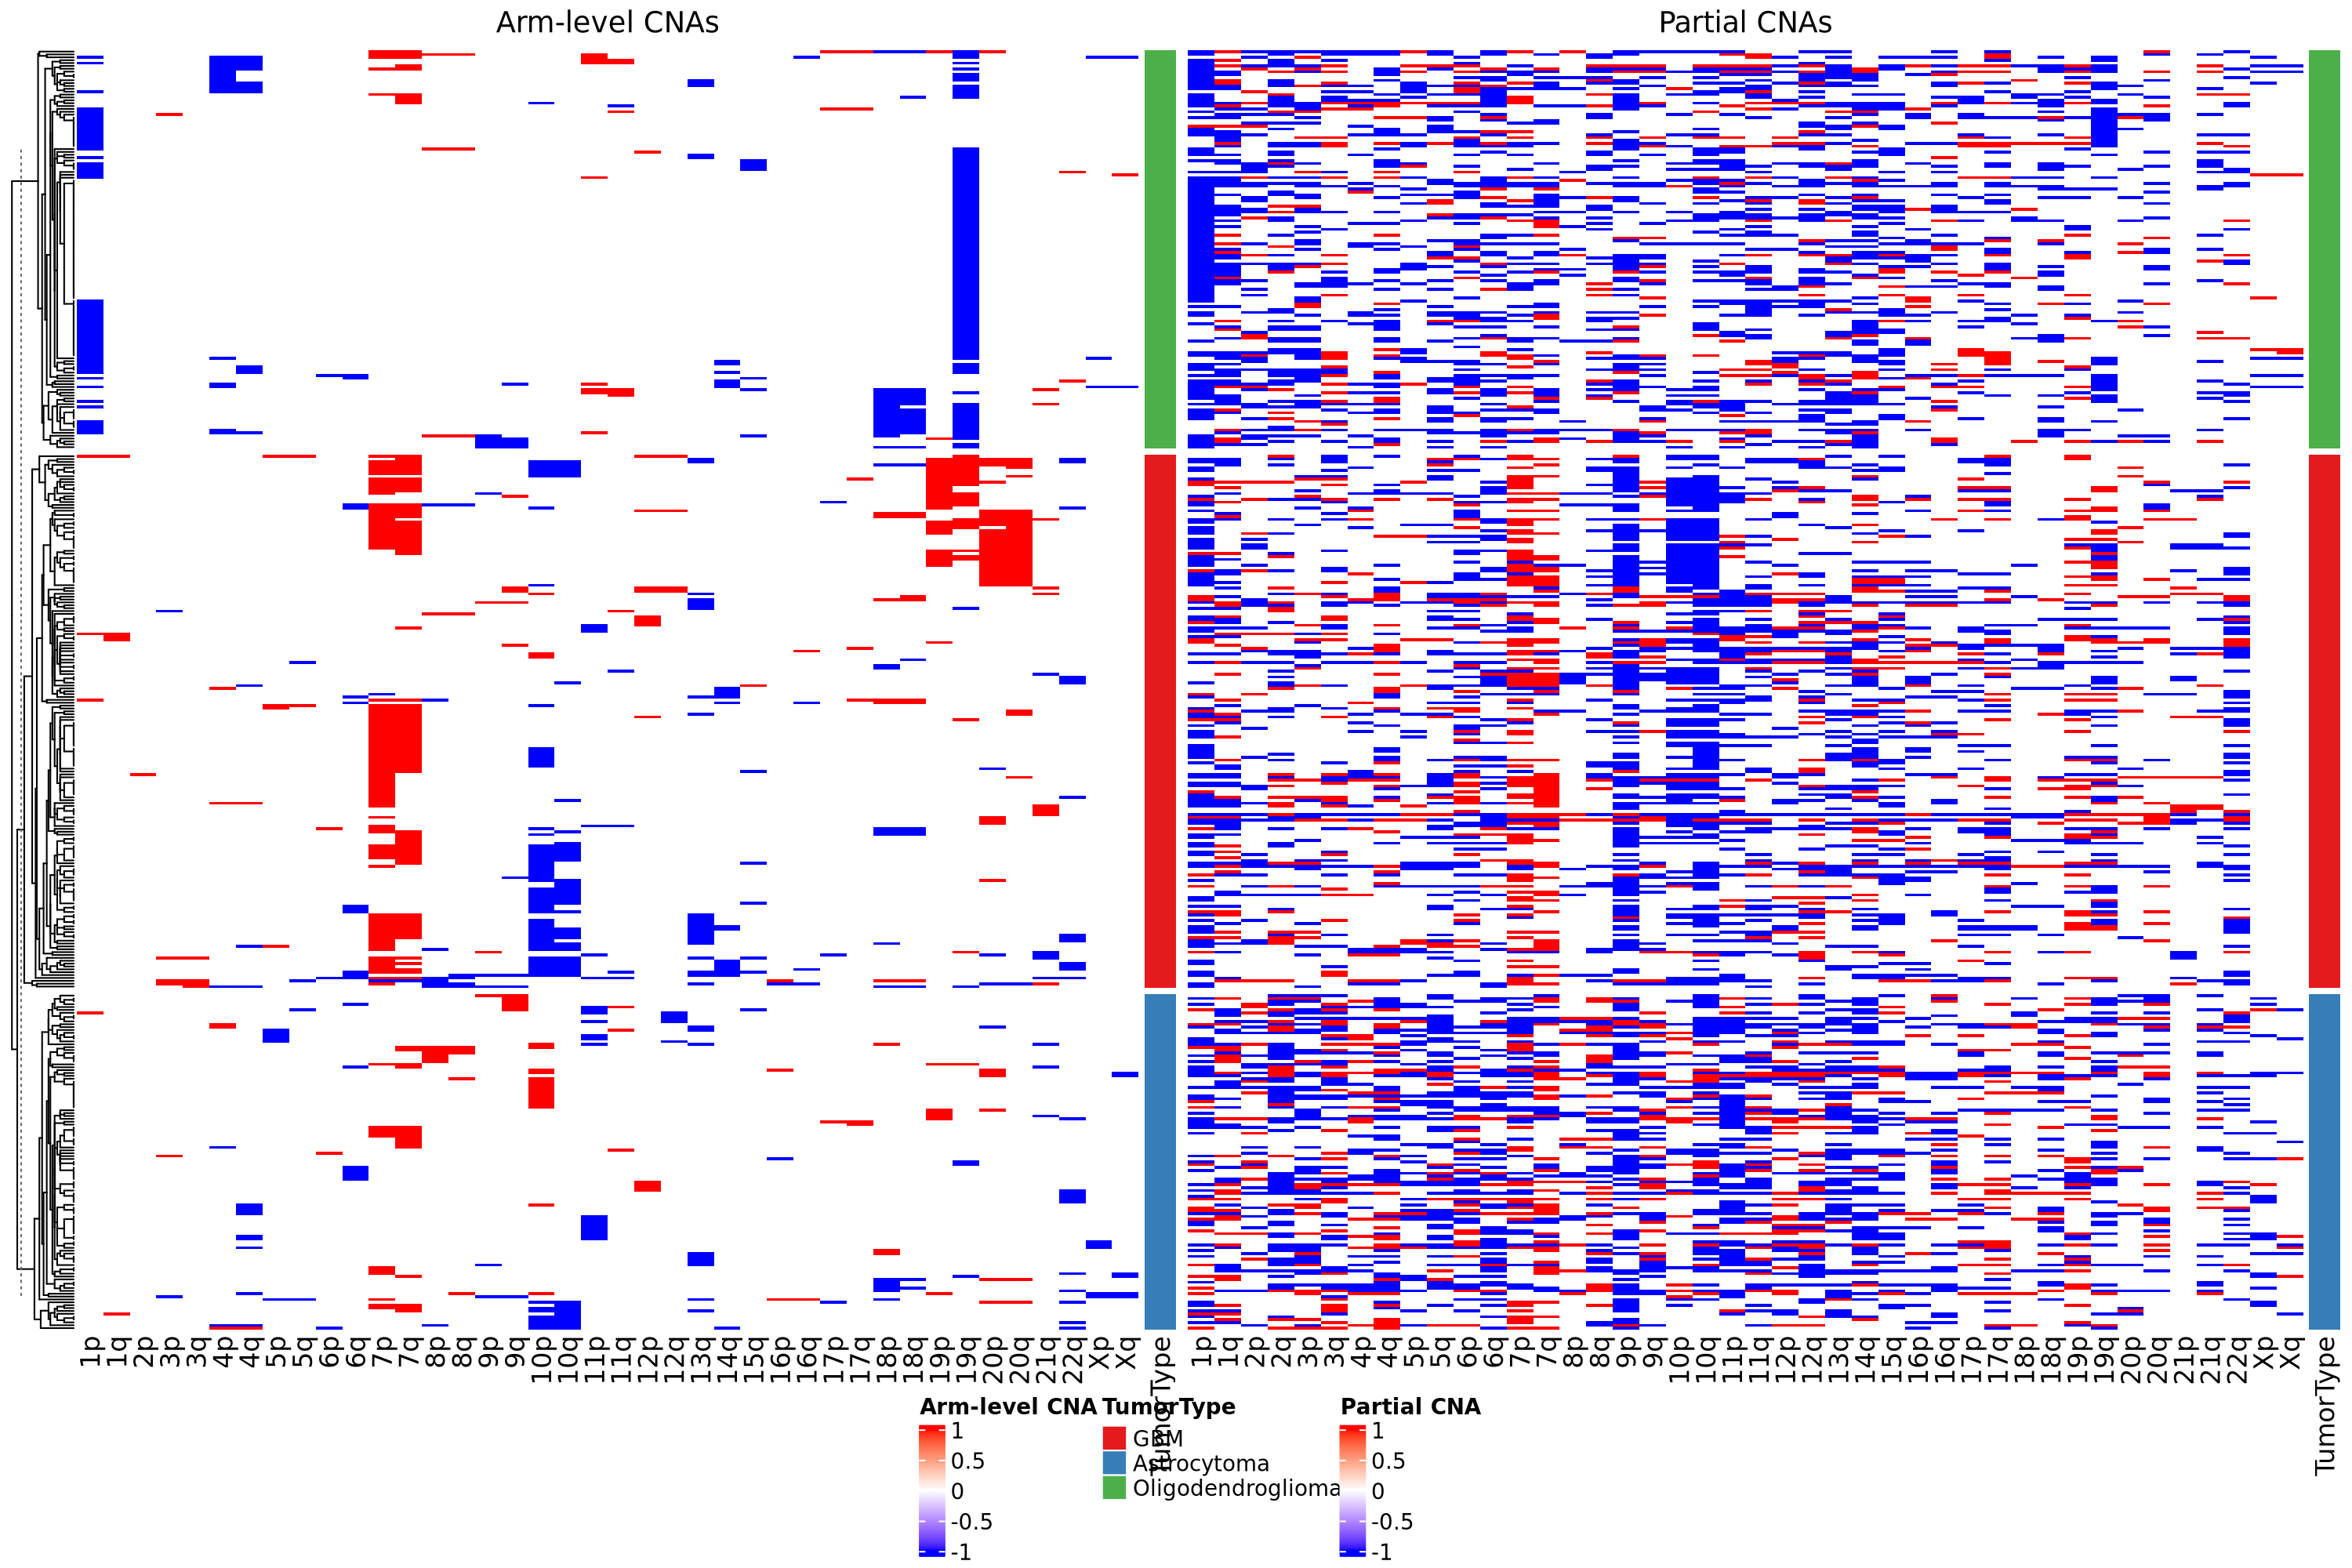

In [214]:
# Get tumor type factor in the order of the rows
row_split_factor <- factor(get_tumor_type(common_samples, arm_level_cnvs),
                           levels = c("GBM", "Astrocytoma", "Oligodendroglioma"))

options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 200)

ht_arm_sub <- Heatmap(arm_level_mat_sub,
                      name = "Arm-level CNA",
                      col = col_fun,
                      right_annotation = ha_arm_row_sub,
                      show_row_names = FALSE,
                      cluster_rows = TRUE,
                      cluster_columns = FALSE,
                      column_title = "Arm-level CNAs",
                      row_split = row_split_factor,
                      row_title = NULL,   # optionally hide row titles if you want
                      cluster_row_slices = TRUE)  # cluster rows within each slice

ht_partial_sub <- Heatmap(partial_mat_sub,
                         name = "Partial CNA",
                         col = col_fun,
                         right_annotation = ha_partial_row_sub,
                         show_row_names = FALSE,
                         cluster_rows = TRUE,
                         cluster_columns = FALSE,
                         column_title = "Partial CNAs",
                         row_split = row_split_factor,
                         row_title = NULL,
                         cluster_row_slices = TRUE)

draw(ht_arm_sub + ht_partial_sub, heatmap_legend_side = "bottom")


In [196]:
head(arm_level_mat_sub)

,1p,1q,2p,3p,3q,4p,4q,5p,5q,6p,⋯,18p,18q,19p,19q,20p,20q,21q,22q,Xp,Xq
GLSS-19-0266-TP,0,0,0,0,0,0,0,1,1,0,⋯,0,0,0,0,0,0,0,0,0,0
GLSS-19-0267-TP,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
GLSS-19-0268-TP,0,0,0,1,1,0,0,0,0,0,⋯,0,0,0,0,-1,-1,1,0,0,0
GLSS-19-0269-R1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
GLSS-19-0269-TP,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
GLSS-19-0270-TP,0,0,0,0,0,0,0,0,0,0,⋯,0,0,1,0,1,1,0,0,0,0


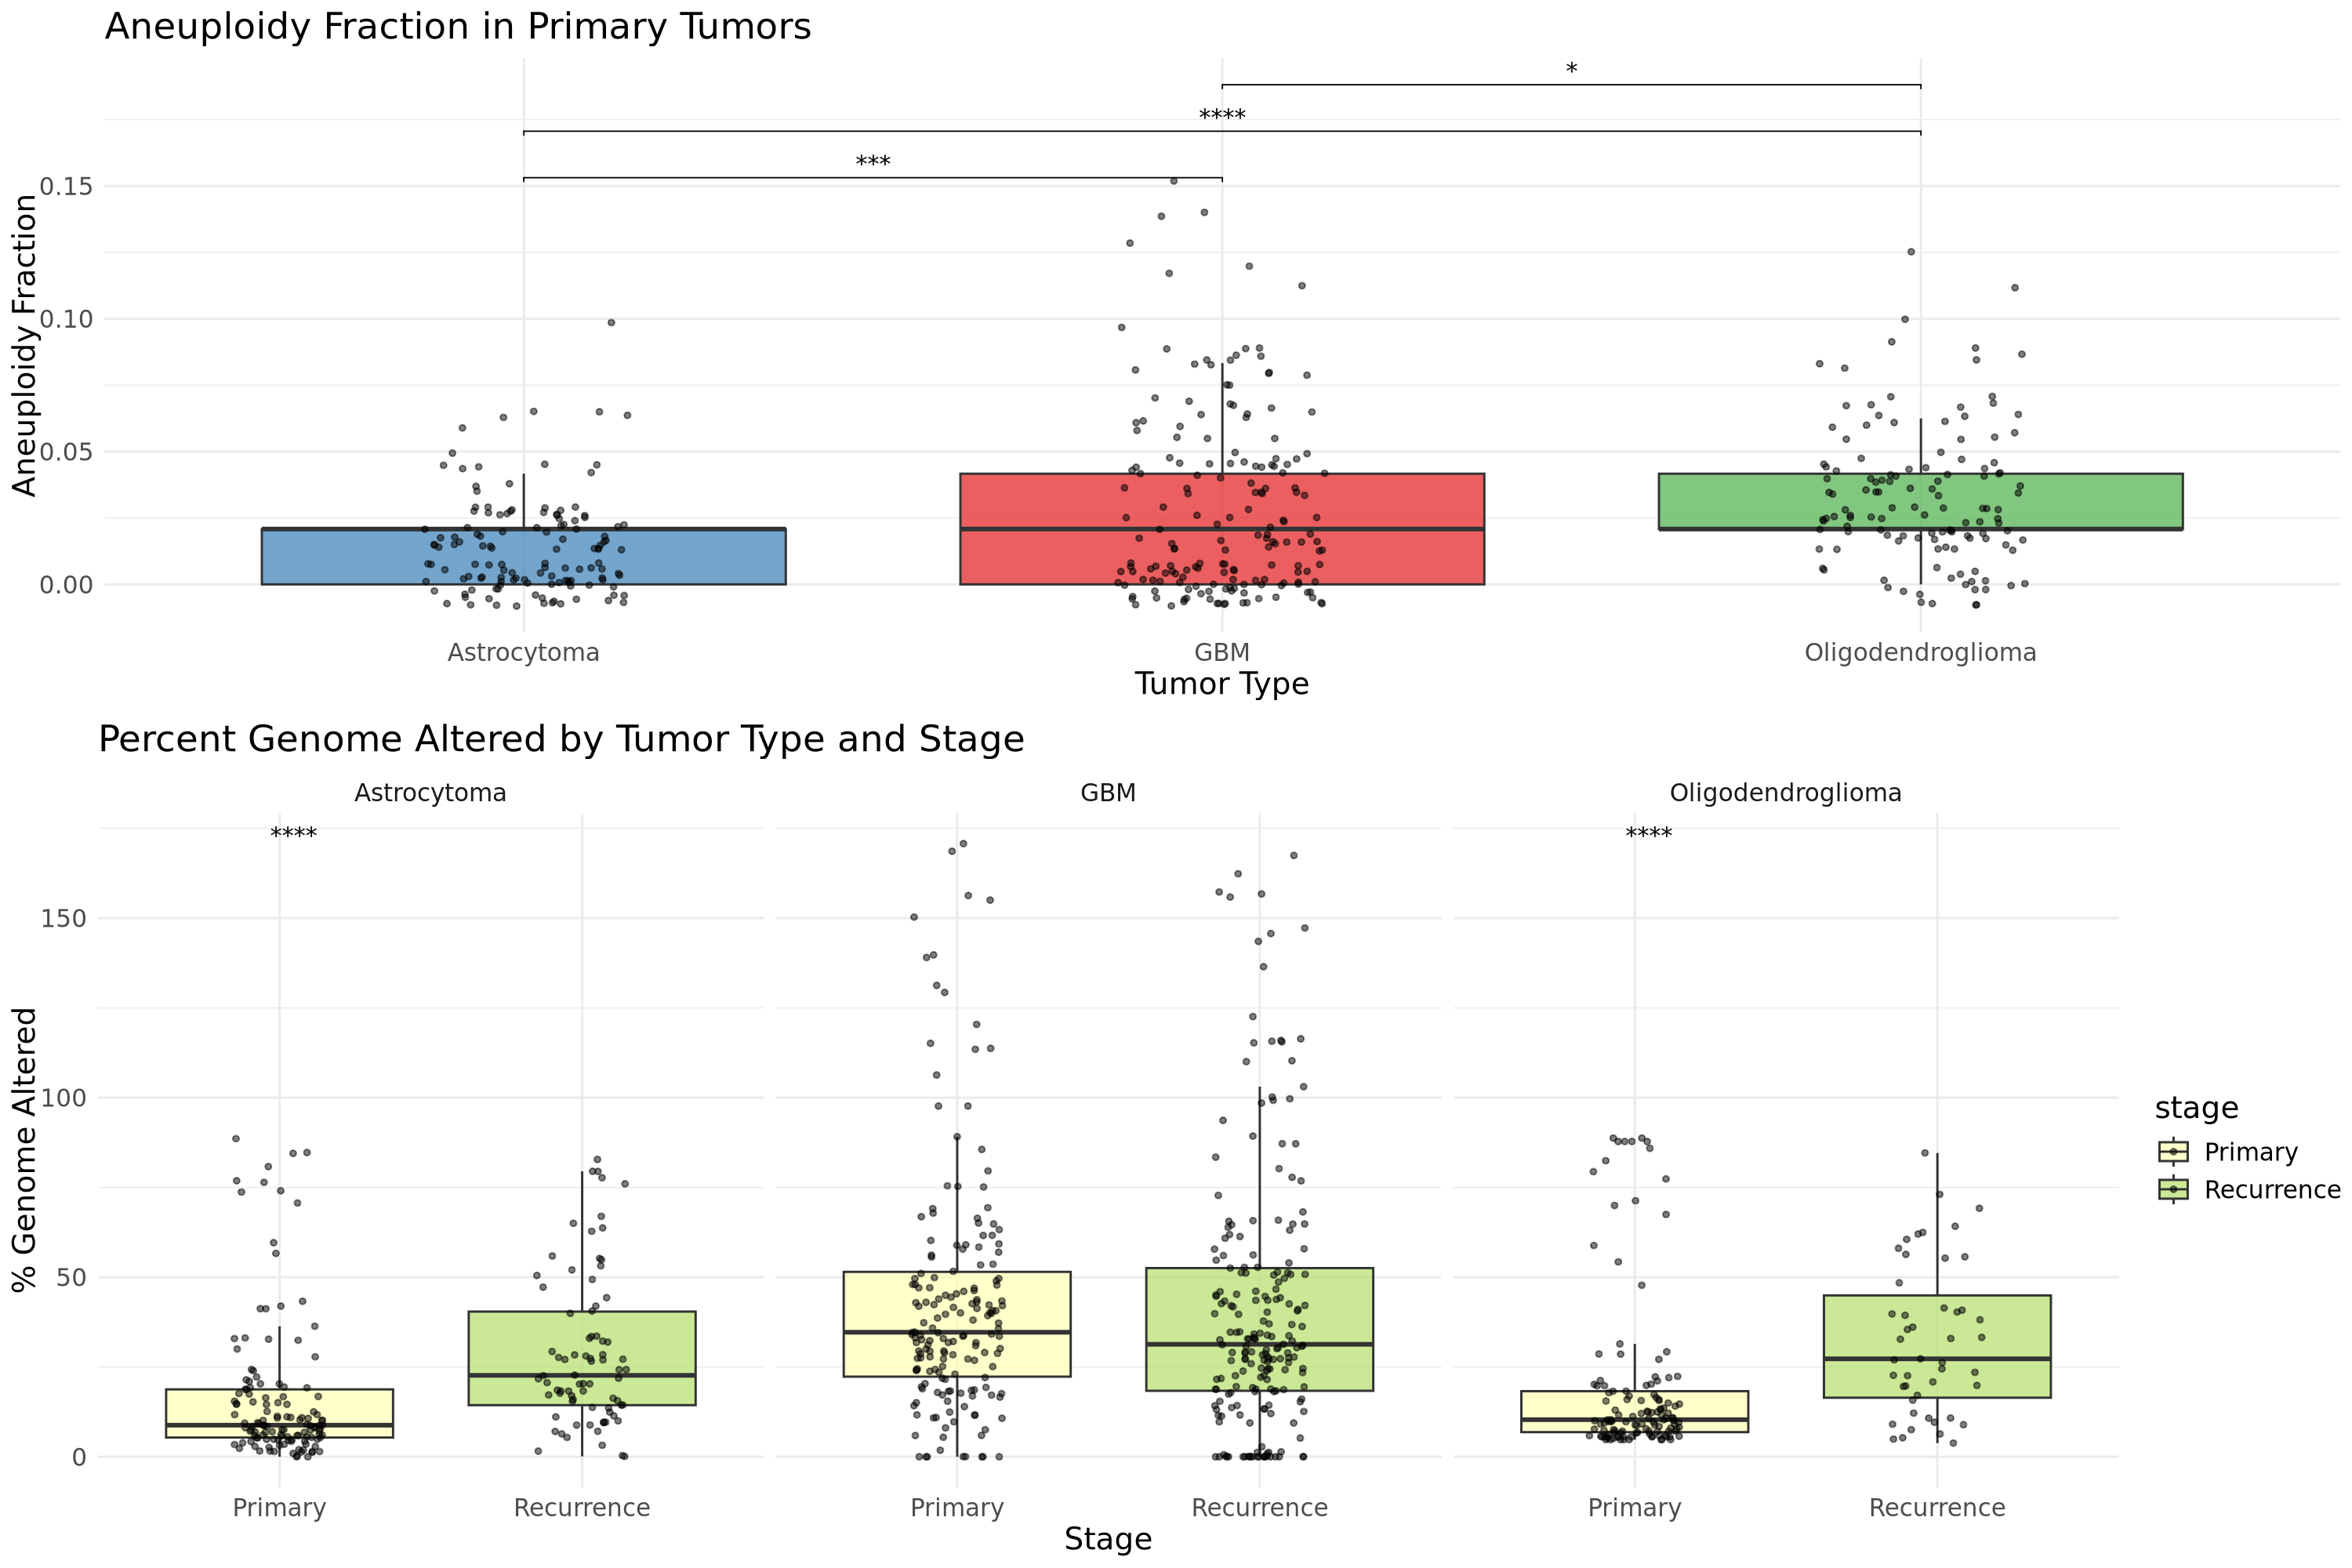

In [197]:
library(dplyr)
library(ggplot2)
library(ggpubr)
library(cowplot)

# ---- Boxplot 1: Aneuploidy Fraction in Primary Tumors ----
p1 <- measures_filt %>%
  filter(stage == "Primary") %>%
  ggplot(aes(x = tumor_type, y = aneuploidy_fraction, fill = tumor_type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.15, size = 1, alpha = 0.5) +
  stat_compare_means(method = "wilcox.test", label = "p.signif", 
                     comparisons = combn(unique(measures_filt$tumor_type[measures_filt$stage == "Primary"]), 2, simplify = FALSE),
                     tip.length = 0.01) +
  scale_fill_manual(values = tumor_colors) +
  labs(title = "Aneuploidy Fraction in Primary Tumors",
       x = "Tumor Type", y = "Aneuploidy Fraction") +
  theme_minimal() +
  theme(legend.position = "none", text = element_text(size = 14))

# ---- Boxplot 2: Percent Genome Altered by Tumor Type and Stage ----
p2 <- measures_filt %>%
  ggplot(aes(x = stage, y = percent_genome_altered, fill = stage)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.15, size = 1, alpha = 0.5) +
  stat_compare_means(method = "wilcox.test", label = "p.signif", 
                     aes(group = stage), 
                     hide.ns = TRUE) +
  facet_wrap(~tumor_type, scales = "free_x") +
  scale_fill_manual(values = c("Primary" = "#FFFFB3", "Recurrence" = "#B3DE69")) +
  labs(title = "Percent Genome Altered by Tumor Type and Stage",
       x = "Stage", y = "% Genome Altered") +
  theme_minimal() +
  theme(text = element_text(size = 14))

# ---- Combine and Show ----
cowplot::plot_grid(p1, p2, ncol = 1, rel_heights = c(1, 1.2))


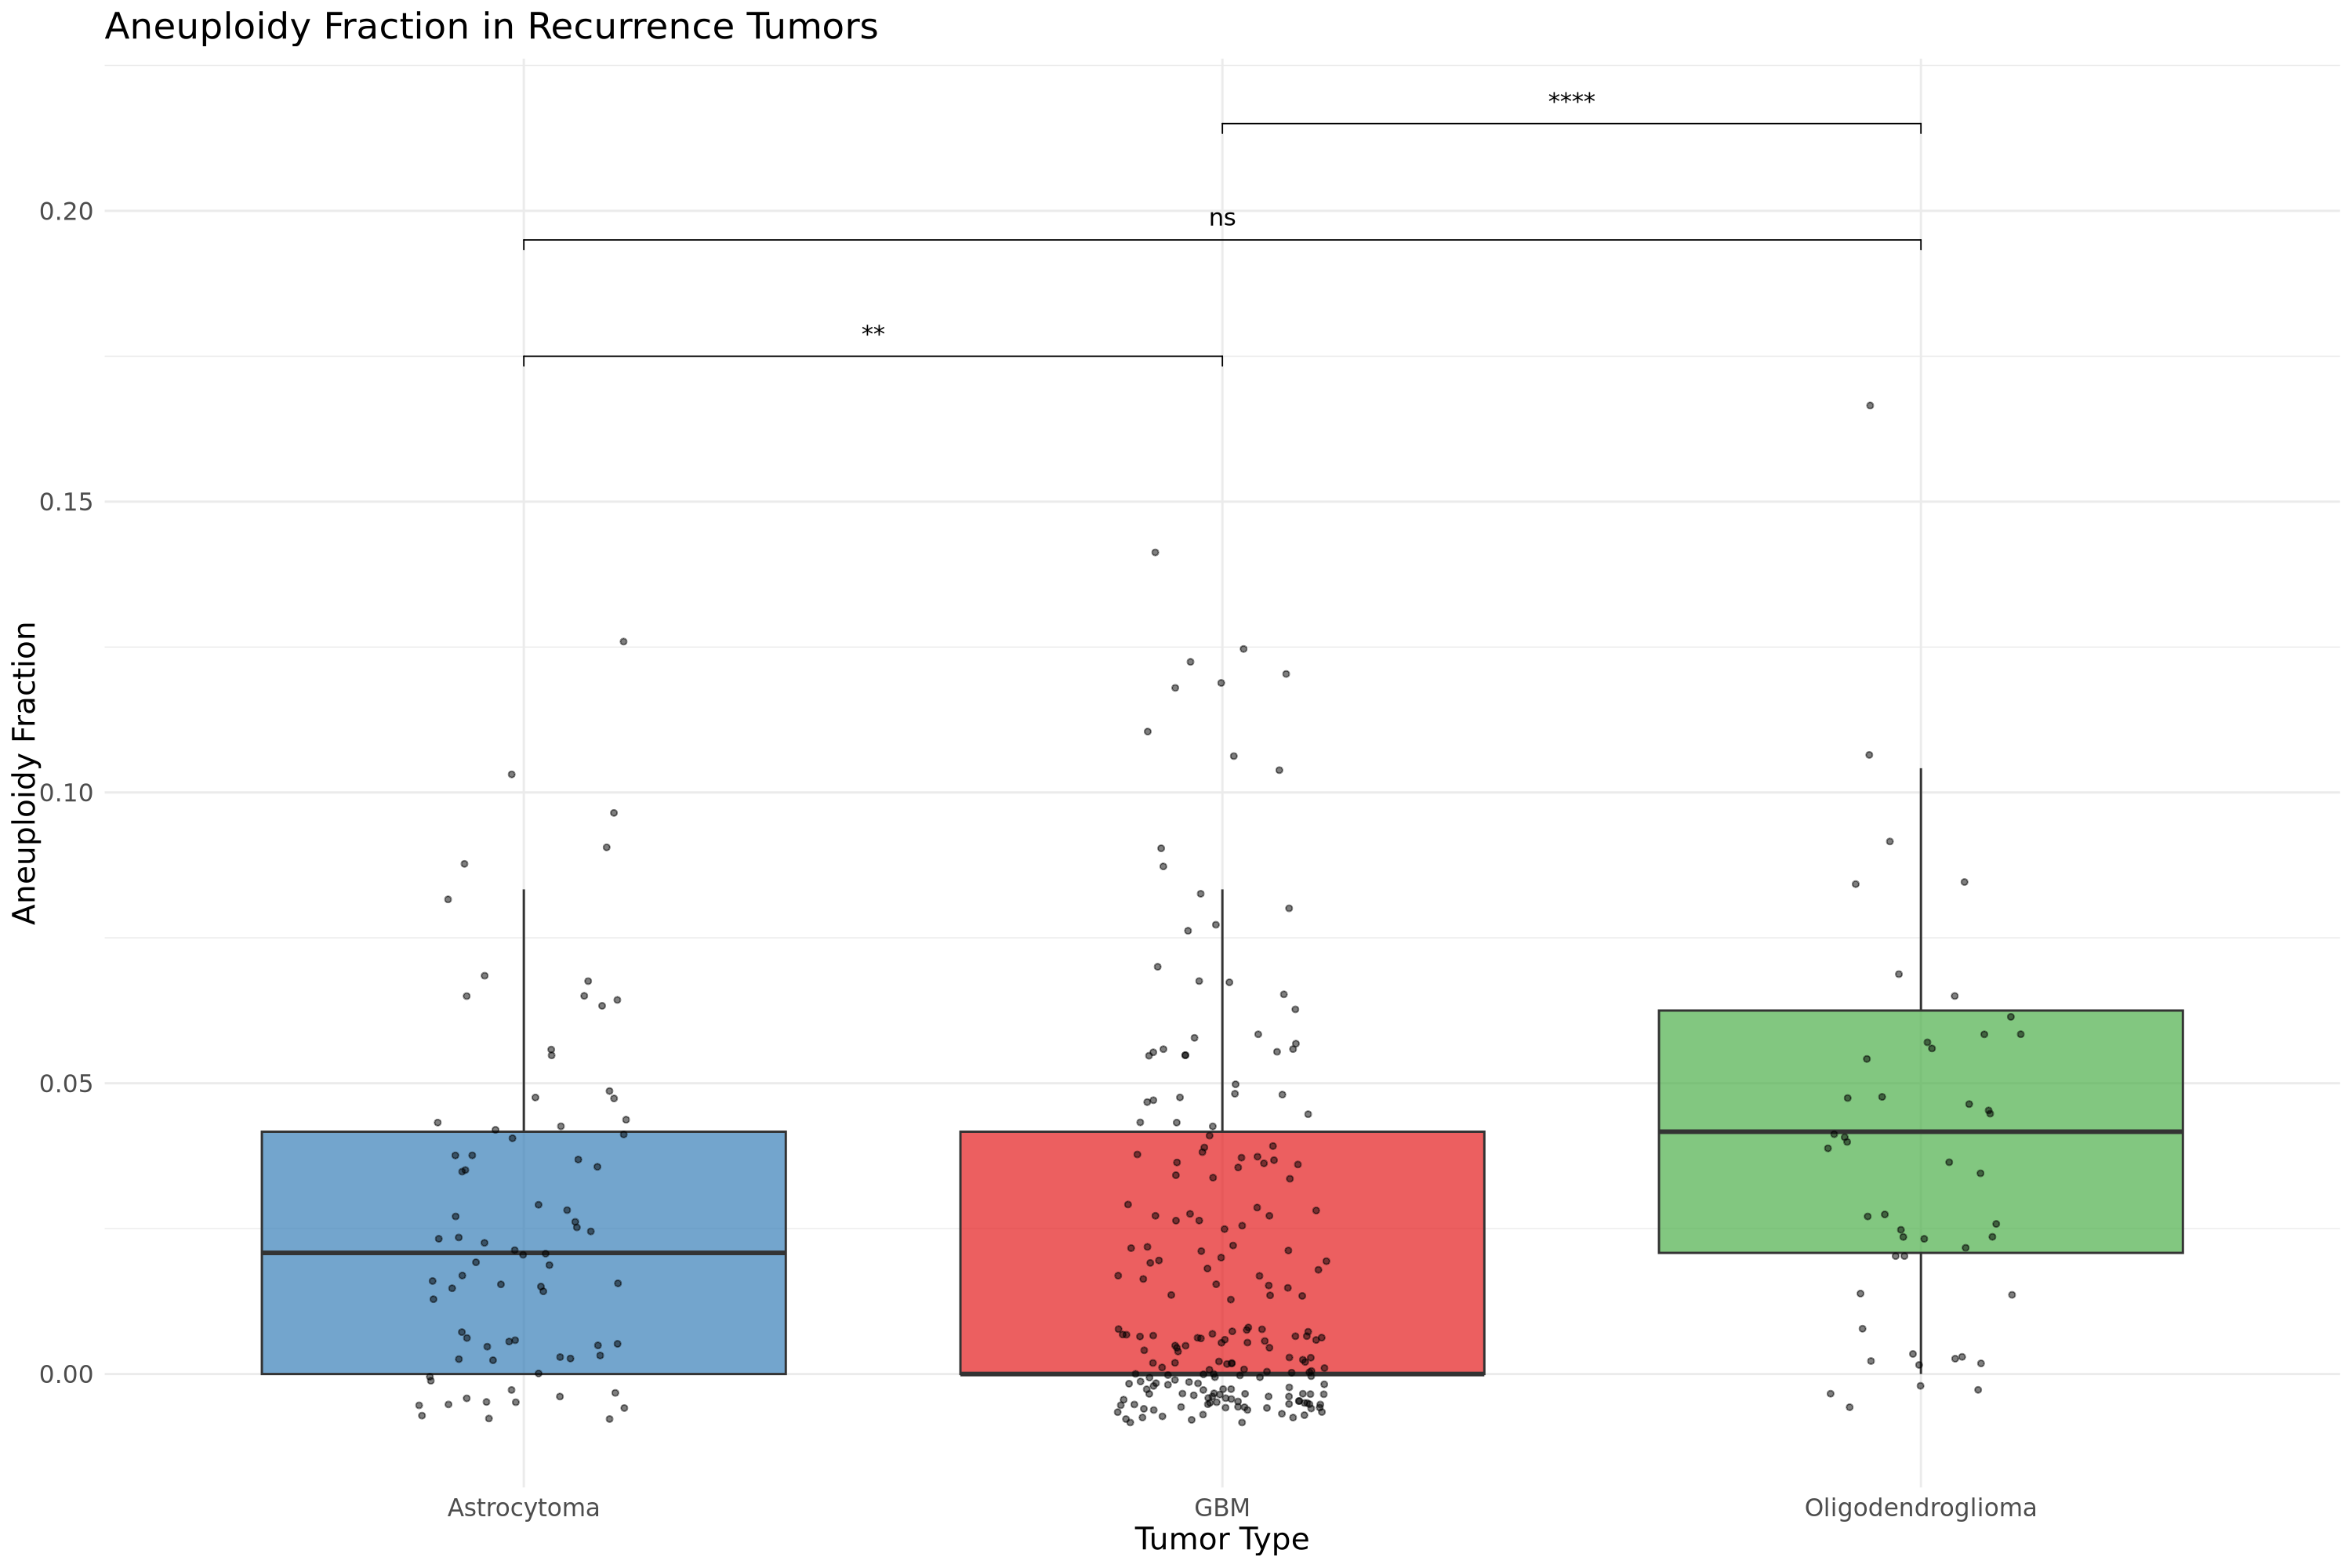

In [198]:
# ---- Boxplot 1: Aneuploidy Fraction in Primary Tumors ----
p1 <- measures_filt %>%
  filter(stage == "Recurrence") %>%
  ggplot(aes(x = tumor_type, y = aneuploidy_fraction, fill = tumor_type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.15, size = 1, alpha = 0.5) +
  stat_compare_means(method = "wilcox.test", label = "p.signif", 
                     comparisons = combn(unique(measures_filt$tumor_type[measures_filt$stage == "Recurrence"]), 2, simplify = FALSE),
                     tip.length = 0.01) +
  scale_fill_manual(values = tumor_colors) +
  labs(title = "Aneuploidy Fraction in Recurrence Tumors",
       x = "Tumor Type", y = "Aneuploidy Fraction") +
  theme_minimal() +
  theme(legend.position = "none", text = element_text(size = 14))
print(p1)

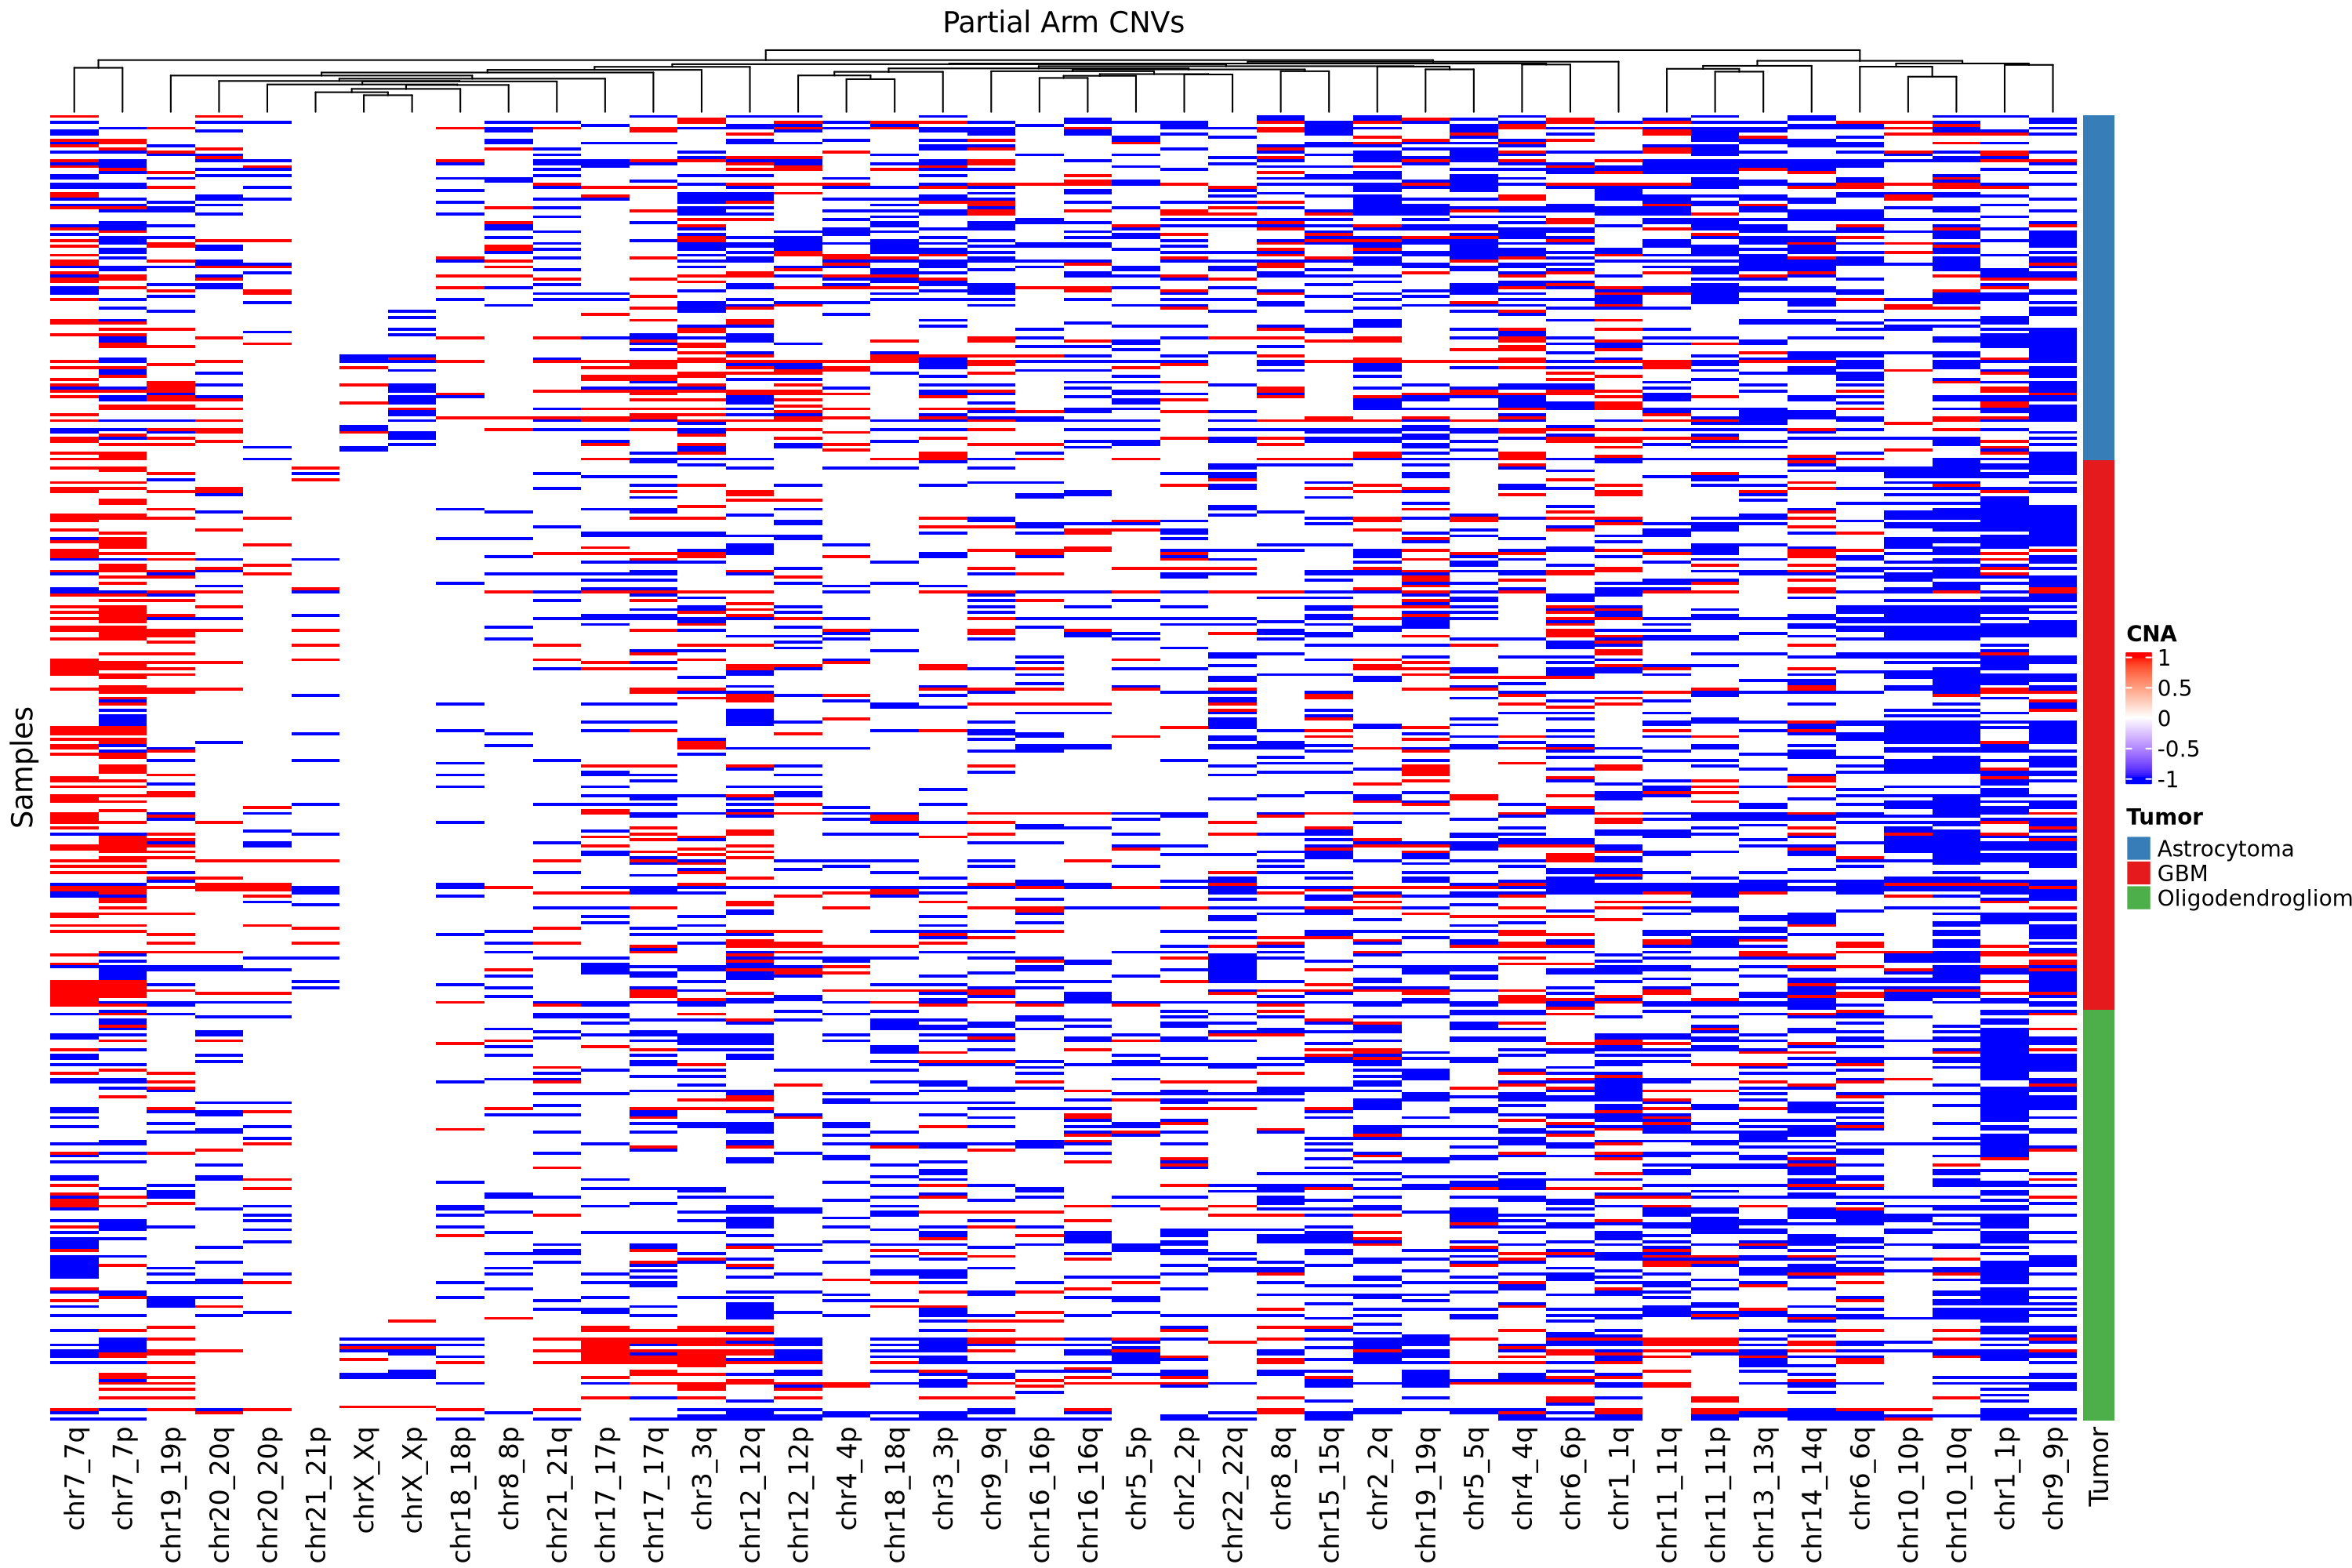

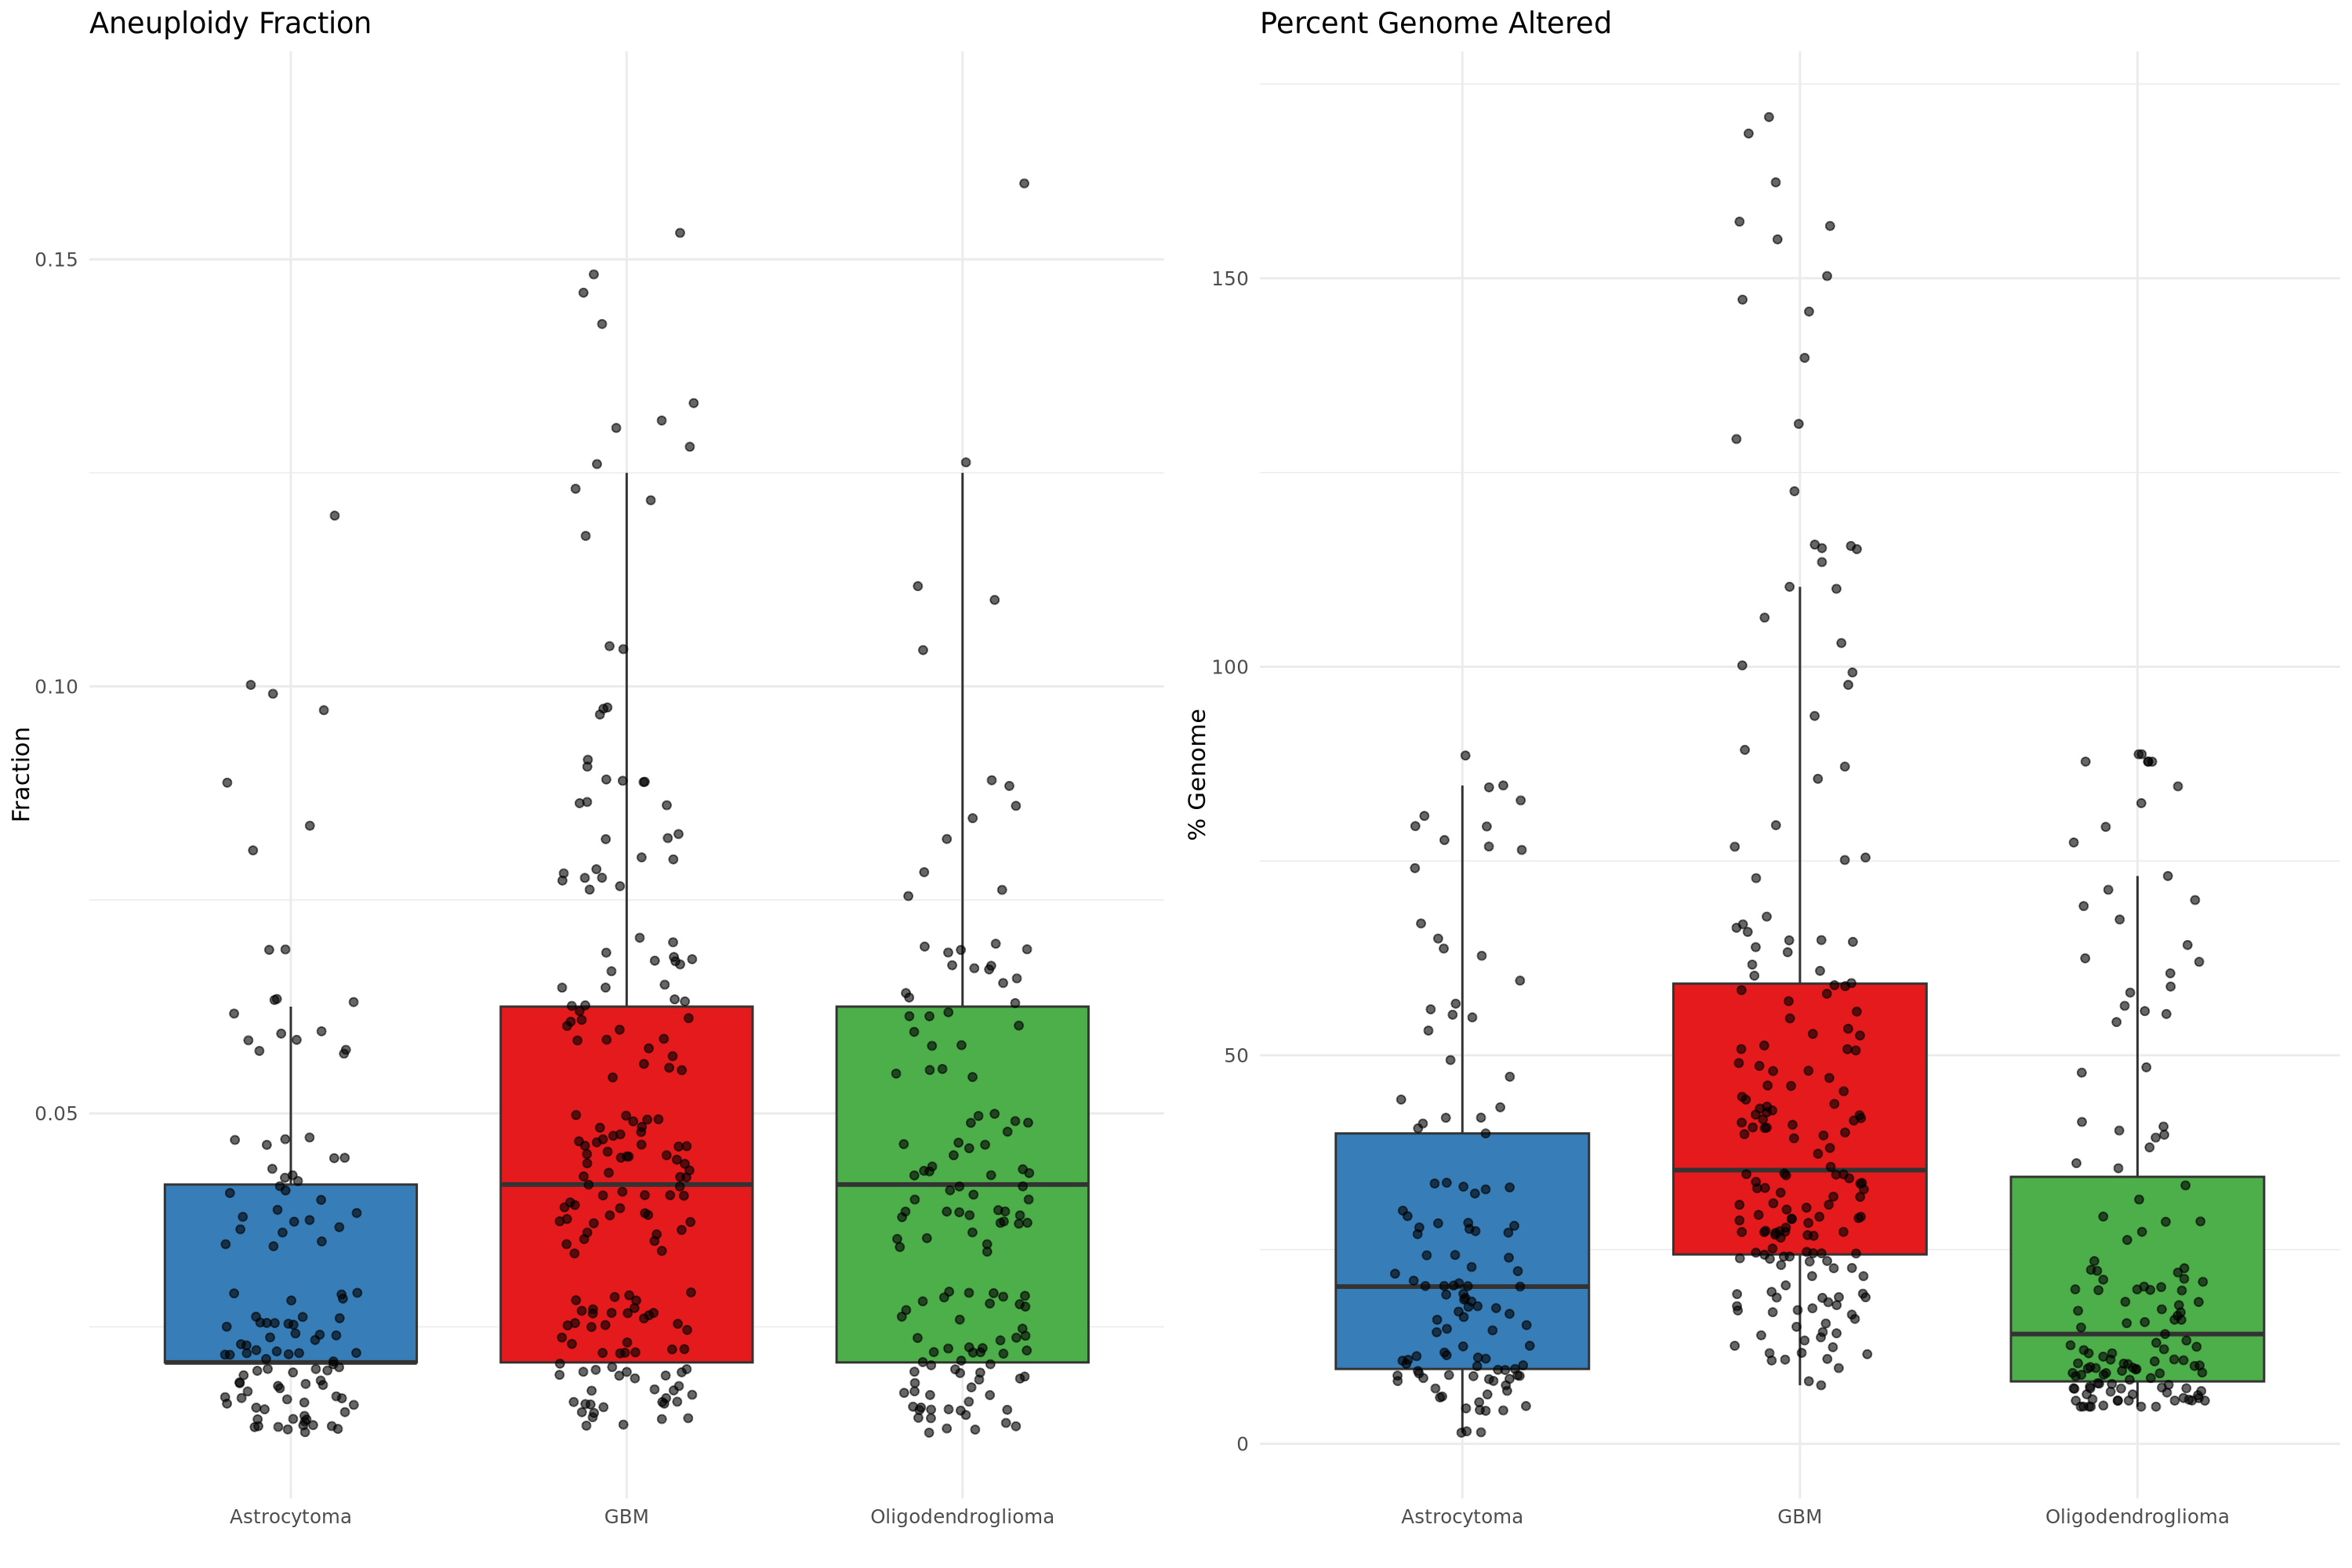

In [203]:
# --- Libraries ---
library(tidyverse)
library(ComplexHeatmap)
library(circlize)
library(cowplot)

# --- Step 0: Data Assumptions ---
# Data frames required: 
# - arm_level_cnvs: sample, tumor_type, stage, region, cna_status
# - partial_cnvs: same structure
# - measures: sample, tumor_type, stage, aneuploidy_fraction, percent_genome_altered

# --- Step 1: Prepare matrices for heatmaps ---

arm_level_mat <- arm_level_cnvs %>%
  group_by(sample, region) %>%
  summarise(cna_status = first(cna_status), .groups = "drop") %>%
  pivot_wider(names_from = region, values_from = cna_status, values_fill = 0) %>%
  column_to_rownames("sample") %>%
  as.matrix()

partial_mat <- partial_cnvs %>%
  group_by(sample, region) %>%
  summarise(cna_status = first(cna_status), .groups = "drop") %>%
  pivot_wider(names_from = region, values_from = cna_status, values_fill = 0) %>%
  column_to_rownames("sample") %>%
  as.matrix()

# --- Step 2: Get common samples across matrices ---

common_samples <- intersect(rownames(arm_level_mat), rownames(partial_mat))

arm_level_mat_sub <- arm_level_mat[common_samples, , drop = FALSE]
partial_mat_sub <- partial_mat[common_samples, , drop = FALSE]

# --- Step 3: Prepare annotation for heatmaps ---

# Tumor type colors
tumor_colors <- c("GBM" = "#E41A1C", "Astrocytoma" = "#377EB8", "Oligodendroglioma" = "#4DAF4A")

# Helper to get tumor type per sample in correct row order
get_tumor_type <- function(samples, df) {
  df %>%
    distinct(sample, tumor_type) %>%
    filter(sample %in% samples) %>%
    arrange(factor(sample, levels = samples)) %>%
    pull(tumor_type)
}

# Row annotation for arm-level and partial
ha_arm <- rowAnnotation(
  TumorType = factor(get_tumor_type(rownames(arm_level_mat_sub), arm_level_cnvs),
                     levels = names(tumor_colors)),
  col = list(TumorType = tumor_colors),
  show_annotation_name = TRUE
)

ha_partial <- rowAnnotation(
  TumorType = factor(get_tumor_type(rownames(partial_mat_sub), partial_cnvs),
                     levels = names(tumor_colors)),
  col = list(TumorType = tumor_colors),
  show_annotation_name = TRUE
)

# --- Step 4: Color function for CNA ---
col_fun <- colorRamp2(c(-1, 0, 1), c("blue", "white", "red"))

# --- Step 5: Filter measures data ---
measures_filt <- measures %>%
  filter(tumor_type %in% c("Astrocytoma", "GBM", "Oligodendroglioma")) %>%
  filter(sample %in% rownames(partial_mat_sub))  # Keep only available samples

# Reorder partial matrix to match annotation
partial_mat_ordered <- partial_mat_sub[measures_filt$sample, , drop = FALSE]

# --- Step 6: Create Heatmap for partial CNVs ---

partial_heatmap <- Heatmap(
  partial_mat_ordered,
  name = "CNA",
  col = col_fun,
  cluster_rows = FALSE,
  cluster_columns = TRUE,
  show_row_names = FALSE,
  show_column_names = TRUE,
  row_title = "Samples",
  column_title = "Partial Arm CNVs",
  right_annotation = rowAnnotation(
    Tumor = measures_filt$tumor_type,
    col = list(Tumor = tumor_colors)
  )
)

# --- Step 7: Boxplots of genomic instability metrics ---

# Create boxplots
p1 <- ggplot(measures_filt, aes(x = tumor_type, y = aneuploidy_fraction, fill = tumor_type)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.6) +
  scale_fill_manual(values = tumor_colors) +
  labs(title = "Aneuploidy Fraction", x = "", y = "Fraction") +
  theme_minimal() +
  theme(legend.position = "none")

p2 <- ggplot(measures_filt, aes(x = tumor_type, y = percent_genome_altered, fill = tumor_type)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.6) +
  scale_fill_manual(values = tumor_colors) +
  labs(title = "Percent Genome Altered", x = "", y = "% Genome") +
  theme_minimal() +
  theme(legend.position = "none")

# --- Step 8: Draw all together ---

# Draw heatmap
draw(partial_heatmap, heatmap_legend_side = "right", annotation_legend_side = "right")

# Plot boxplots
plot_grid(p1, p2, ncol = 2)
